# Dynamic Deblurring: Four-Way Comparison

This notebook compares **four** solvers on a dynamic (multi-frame) deblurring problem:



## 1. Imports

In [887]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.linalg as la
import scipy.sparse as sparse
import matplotlib.pyplot as plt

# --- trips package ---
from ttrips.tensors.ops import t_prod2, t_transpose, t_normalize, tQR, t_svd, tubal_inner
from ttrips.tensors.build import build_tensor_A, build_circular_H, tensorize, unfold
from ttrips.solvers.gkb import t_gkb
from ttrips.solvers.trmmgks import smoothed_holder_weights_tensor
# Note: we DON'T import Lx_tensor / Ly_tensor from ttrips.tensors.derivatives — the
# originals return shape (ny, ny, nx), which only works when NX == NY. We define
# corrected versions below with shape (NX, NX, NY), consistent with build_tensor_A
# and the data convention used throughout this notebook.

# # --- dynamic solver (drop dynamic_solver.py and temporal_ops.py next to this notebook) ---
# from dynamic_solver import tRMMGKS_dynamic
# from temporal_ops import first_difference_matrix, apply_Lt, apply_LtT

# --- matrix solver ---
from ttrips.solvers.rmmgks import RMMGKS

# --- problem generator ---
from helpers import generate_problem

print('Imports OK.')

Imports OK.


## 2. Helpers

A few utilities for this notebook: a Gaussian PSF builder, derivative operators
for the matrix formulation (1D, 2D spatial, 3D space-time), and a routine to
build the stacked dynamic blur operator.

In [888]:
def gaussian_kernel_2d(k: int, sigma: float = None) -> np.ndarray:
    """Build a k×k isotropic Gaussian PSF, normalized to sum to 1."""
    if sigma is None:
        sigma = max(0.5, 0.3 * (k // 2 - 1) + 0.8)
    center = (k - 1) / 2
    x = np.arange(k) - center
    X, Y = np.meshgrid(x, x, indexing='ij')
    kernel = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

In [1028]:
# ── Matrix-form derivative operators (your existing definitions) ─────────────

def gen_first_derivative_operator(n):
    """1D forward-difference matrix (n-1) × n, zero boundary."""
    D = sparse.diags(diagonals=np.ones(n - 1), offsets=1, shape=(n, n)).tocsr()
    L = (sparse.identity(n) - D).tocsr()
    return L[0:-1, :]


def gen_first_derivative_circular(n):
    """1D circular forward-difference matrix n × n, periodic boundary."""
    e = np.ones(n)
    D = sparse.diags([-e, e], [0, 1], shape=(n, n)).tolil()
    D[-1, 0] = 1
    D[-1, -1] = -1
    return D.tocsr()


def gen_first_derivative_operator_2D(nx, ny):
    """2D spatial gradient (zero-boundary) for matrix solver."""
    D_x = gen_first_derivative_operator(nx)
    D_y = gen_first_derivative_operator(ny)
    IDx = sparse.kron(sparse.identity(nx), D_x)
    DyI = sparse.kron(D_y, sparse.identity(ny))
    return sparse.vstack((IDx, DyI))


def gen_first_derivative_operator_2D_circular(nx, ny):
    """2D spatial gradient (periodic) for matrix solver, F-order convention.

    Under F-order (column-major) flattening, vec_F(X) has X[i,j] at position
    j*nx + i (column j stacked atop column j+1). Then:
      - row-direction differences: kron(I_ny, D_x)
      - col-direction differences: kron(D_y, I_nx)

    Note: this is the OPPOSITE Kronecker order from C-order conventions.
    Make sure all reshapes in this notebook use order='F' to stay consistent."""
    D_x = gen_first_derivative_circular(nx)
    D_y = gen_first_derivative_circular(ny)
    Iny_Dx = sparse.kron(sparse.identity(ny), D_x)   # row-direction
    Dy_Inx = sparse.kron(D_y, sparse.identity(nx))   # col-direction
    return sparse.vstack((Iny_Dx, Dy_Inx))


def gen_spacetime_derivative_operator(nx, ny, nt):
    """Space + time gradient operator for the matrix solver, F-order convention.

    Stacks I_t ⊗ L_spatial above L_t ⊗ I_xy, where:
      - L_spatial uses the F-order 2D gradient
      - The full vector is x_F = [vec_F(frame_0); vec_F(frame_1); ...; vec_F(frame_{nt-1})]
        so frames stack in the OUTER index, exactly matching what
        sparse.kron(sparse.identity(nt), L_spatial) wants.
      - Lt is zero-boundary (videos aren't cyclic in time)."""
    D_spatial = gen_first_derivative_operator_2D_circular(nx, ny)
    Lt = gen_first_derivative_operator(nt)   # zero-boundary time
    IT_Ls = sparse.kron(sparse.identity(nt), D_spatial)
    Lt_Ixy = sparse.kron(Lt, sparse.identity(nx * ny))
    return sparse.vstack((IT_Ls, Lt_Ixy))

In [1029]:
# ── Tensor-form spatial derivative operators (corrected shape conventions) ──

def Lx_tensor_dyn(NX, NY):
    """Row-direction differences (mode 1 of each frontal slice, periodic BC).
    Shape (NX, NX, NY) — consistent with build_tensor_A and the data convention.

    Encoded by placing D_x in frontal slice 0 only. After FFT along mode 3,
    every Fourier face equals D_x, so the t-product applies D_x to every column
    of every frontal slice."""
    D = gen_first_derivative_circular(NX).toarray()
    L = np.zeros((NX, NX, NY))
    L[:, :, 0] = D
    return L


def Ly_tensor_dyn(NX, NY):
    """Column-direction differences (mode 3, periodic BC by t-product convolution).
    Shape (NX, NX, NY).

    Encoded as -I in slice 0 and +I in slice -1. The t-product convolution along
    mode 3 then *is* the circular forward-difference along the column axis."""
    L = np.zeros((NX, NX, NY))
    L[:, :, 0] = -np.eye(NX)
    L[:, :, -1] = np.eye(NX)
    return L


def t_vstack_dyn(A, B):
    """Stack two tensor operators along axis 0 (the row axis of frontal slices).
    For A of shape (a, m, n) and B of shape (b, m, n), returns (a+b, m, n)."""
    return np.concatenate([A, B], axis=0)

In [891]:
# ── Build dynamic blur operator (matrix form) ───────────────────────────────

def build_dynamic_blur_matrix(H_spatial, n_t):
    """Block-diagonal across frames: same spatial blur applied independently to each.

    Returns
    -------
    H_big : sparse (nx*ny*n_t) × (nx*ny*n_t)
    """
    H_sparse = sparse.csr_matrix(H_spatial)
    return sparse.kron(sparse.identity(n_t), H_sparse)

## 3. Experiment configuration

In [1125]:
# ── Image & blur ──────────────────────────────────────────────────────────
PHANTOM1      = 'blocks'         # 'blocks' is best for showing temporal-reg value
NX, NY       = 64,64        # ke6ep equal for the t-product convention
N_T1          = 20               # number of frames
N_T2          = 20               # number of frames
KERNEL_SIZE  = 5
KERNEL_SIGMA = 1.5
PHANTOM2      = 'mnist'  
N_T          = N_T1 + N_T2
# ── Noise ─────────────────────────────────────────────────────────────────
NOISE_LEVEL  = 0.01


## 4. Build the dynamic problem

We use the `blocks` phantom which generates `n_t` frames of moving blocks. The
forward operator applies the same Gaussian blur independently to each frame.

In [1126]:
# ── Generate true dynamic image ────────────────────────────────────────────
data1 = generate_problem(
    phantom_name=PHANTOM1, nx=NX, ny=NY, t_end=N_T1,
    v_max=1, v_min=0, padding=1, root='', add=0,
)
data2 = generate_problem(
    phantom_name=PHANTOM2, nx=NX, ny=NY, t_end=N_T2,
    v_max=1, v_min=0, padding=1, root='', add=0,
) if PHANTOM2 else None
# data['u_traj'] is a list of n_t flattened frames, each (nx*ny,).
# generate_problem returns frames in some flattening — we'll trust whichever
# convention it uses for going .reshape(NX, NY) and check the agreement test below.
# All vec ↔ matrix conversions in this notebook use F-order (column-major) so
# they line up with bcirc/unfold from the Kilmer–Martin framework.

# Tensor view: (NX, n_t, NY) — frames in mode 2
X_true_tensor = np.stack(
    [u.reshape(NX, NY) for u in data1['u_traj']]+[u.reshape(NX, NY) for u in data2['u_traj']], axis=1
) if data2 else np.stack(
    [u.reshape(NX, NY) for u in data1['u_traj']], axis=1
)
print(f'Tensor X_true shape: {X_true_tensor.shape}')

# Matrix view: stacked vector (n_t * NX * NY, 1), F-order within each frame
# vec_F([X_true_tensor[:, t, :]]) at position j*NX + i = X_true_tensor[i, t, j]
x_true_matrix = np.concatenate(
    [X_true_tensor[:, t, :].reshape(-1, 1, order='F') for t in range(N_T)], axis=0
)
print(f'Matrix x_true shape: {x_true_matrix.shape}')

Problem Description:
- Phantom: blocks
- Image size: 64 x 64
- Number of frames: 20
- Output directory: /problem_64_by_64_blocks_20260619_122343

Problem Description:
- Phantom: mnist
- Image size: 64 x 64
- Number of frames: 20
- Output directory: /problem_64_by_64_mnist_20260619_122343

Tensor X_true shape: (64, 40, 64)
Matrix x_true shape: (163840, 1)


In [1127]:
# ── Build forward operators ───────────────────────────────────────────────
kernel = gaussian_kernel_2d(KERNEL_SIZE, KERNEL_SIGMA)

# Tensor blur: (NX, NX, NY) — applies same blur to every frame via t-product
H_T = build_tensor_A(kernel, NX)

# Matrix blur per frame: bcirc(H_T) is the canonical Kilmer–Martin matricization.
# It satisfies, by construction:
#     bcirc(H_T) @ unfold(X_tens)  ==  unfold(t_prod2(H_T, X_tens))
# where unfold stacks frontal slices on top of each other, which is exactly
# F-order (column-major) flattening of the 2D image: vec_F(X[i,j]) at position
# j*NX + i. So the matrix solver works in the F-order convention throughout.
#
# This is the *exact* matrix counterpart of the t-product — not a re-derivation
# from the kernel — so the two formulations are guaranteed to compute the same
# linear map regardless of kernel symmetry.
from ttrips.tensors.build import bcirc

H_per_frame = bcirc(H_T)
print(f'H_per_frame shape: {H_per_frame.shape}  (= bcirc(H_T))')

# Stacked block-diagonal blur for the matrix solver
H_big = build_dynamic_blur_matrix(H_per_frame, N_T)
print(f'H_big shape: {H_big.shape}')

H_per_frame shape: (4096, 4096)  (= bcirc(H_T))
H_big shape: (163840, 163840)


In [1128]:
# ── Build regularization operators ────────────────────────────────────────

# Tensor spatial reg: stacked Lx + Ly, shape (2*NX, NX, NY)
Lx_tens = Lx_tensor_dyn(NX, NY)
Ly_tens = Ly_tensor_dyn(NX, NY)
L_spatial_tens = t_vstack_dyn(Lx_tens, Ly_tens)

# Tensor temporal reg matrix: shape (n_t-1, n_t)


# Matrix spatial reg per frame: 2D gradient, periodic BC to match tensor
L_spatial_per_frame = gen_first_derivative_operator_2D_circular(NX, NY)

# Matrix reg WITHOUT temporal: I_t ⊗ L_spatial — independent across frames
L_mat_spatial = sparse.kron(sparse.identity(N_T), L_spatial_per_frame)

# Matrix reg WITH temporal: full space-time gradient
L_mat_spacetime = gen_spacetime_derivative_operator(NX, NY, N_T)

L_t = first_difference_matrix(N_T)

print(f'L_spatial_tens shape : {L_spatial_tens.shape}')
print(f'L_t shape            : {L_t.shape}')
print(f'L_mat_spatial shape  : {L_mat_spatial.shape}')
print(f'L_mat_spacetime shape: {L_mat_spacetime.shape}')

L_spatial_tens shape : (128, 64, 64)
L_t shape            : (39, 40)
L_mat_spatial shape  : (327680, 163840)
L_mat_spacetime shape: (487424, 163840)


In [1129]:
# ── Generate clean and noisy data ─────────────────────────────────────────

# Tensor: B = H_T ⋆ X_true, shape (NX, n_t, NY)
B_clean_tensor = t_prod2(H_T, X_true_tensor)

# Matrix: b = H_big @ x_true, shape (n_t*NX*NY, 1)
b_clean_matrix = H_big @ x_true_matrix

# Verify the two formulations agree on the clean data.
# Each frame's tensor slice B_clean_tensor[:, t, :] of shape (NX, NY) maps to
# a length-NX*NY vector via F-order flattening (consistent with x_true_matrix
# and bcirc/unfold).
b_clean_from_tensor = np.concatenate(
    [B_clean_tensor[:, t, :].reshape(-1, 1, order='F') for t in range(N_T)], axis=0
)
agree = la.norm(b_clean_matrix - b_clean_from_tensor) / la.norm(b_clean_matrix)
print(f'Tensor vs matrix forward operator agreement: {agree:.2e}')
if agree > 1e-10:
    print('WARNING: forward operators disagree at machine precision —')
    print('  this should NOT happen with bcirc + F-order. Check that:')
    print('  1. data["u_traj"] frames are stored such that .reshape(NX, NY) '
          'gives the same image as the tensor slice X_true_tensor[:, t, :].')
    print('  2. bcirc and t_prod2 are consistent (they should be, by definition).')

# Add noise
rng = np.random.default_rng(seed=42)
noise = rng.standard_normal(b_clean_matrix.shape)
e = NOISE_LEVEL * la.norm(b_clean_matrix) / la.norm(noise) * noise
delta = la.norm(e)
b_noisy_matrix = b_clean_matrix + e

# Reshape noise for tensor form (F-order, matching x_true_matrix)
e_tensor = np.zeros_like(B_clean_tensor)
for t in range(N_T):
    e_tensor[:, t, :] = e[t * NX * NY:(t + 1) * NX * NY].reshape(NX, NY, order='F')
B_noisy_tensor = B_clean_tensor + e_tensor

print(f'Noise level: {NOISE_LEVEL}  (||e|| = {delta:.4f})')
print(f'SNR        : {20 * np.log10(la.norm(b_clean_matrix) / delta):.1f} dB')

Tensor vs matrix forward operator agreement: 2.46e-16
Noise level: 0.01  (||e|| = 1.3253)
SNR        : 40.0 dB


## 5. Visualize the problem

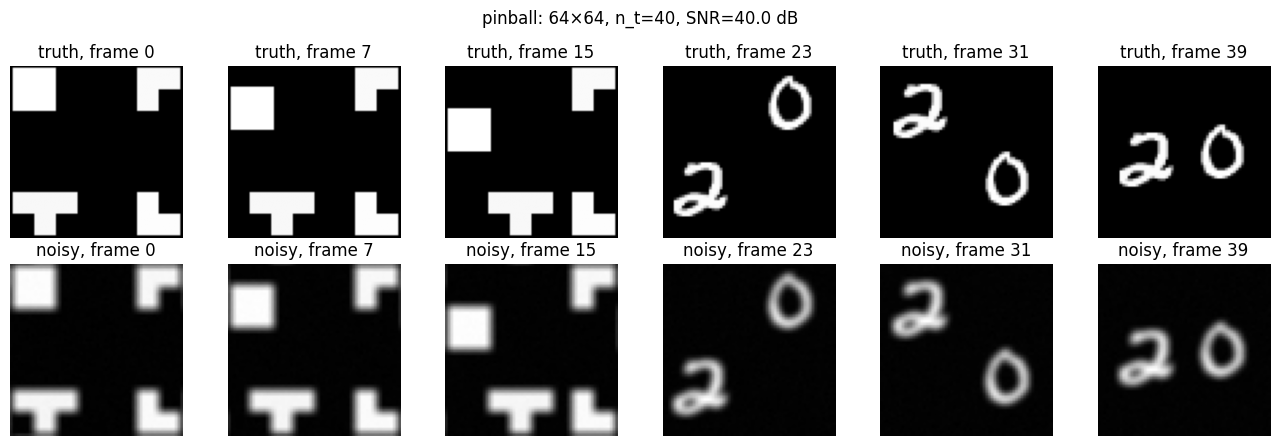

In [1130]:
# Show a few frames of true and noisy
n_show = min(N_T, 6)
fig, axs = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.5))
vmin, vmax = X_true_tensor.min(), X_true_tensor.max()

frame_idxs = np.linspace(0, N_T - 1, n_show, dtype=int)
for j, t in enumerate(frame_idxs):
    axs[0, j].imshow(X_true_tensor[:, t, :], cmap='gray', vmin=vmin, vmax=vmax)
    axs[0, j].set_title(f'truth, frame {t}')
    axs[0, j].axis('off')
    axs[1, j].imshow(B_noisy_tensor[:, t, :], cmap='gray')
    axs[1, j].set_title(f'noisy, frame {t}')
    axs[1, j].axis('off')

axs[0, 0].set_ylabel('truth', fontsize=11)
axs[1, 0].set_ylabel('observed', fontsize=11)
plt.suptitle(f'{PHANTOM}: {NX}×{NY}, n_t={N_T}, SNR={20*np.log10(la.norm(b_clean_matrix)/delta):.1f} dB',
             fontsize=12)
plt.tight_layout()
plt.show()

In [1132]:
def RMMGKS_complex(A, b, L, pnorm=2, qnorm=1, projection_dim=3, n_iter=5, regparam='gcv', x0 = None, V0 = None, x_true=None, power = 1, 
tqdm_ = True,kmin=3,l_max = 5,l_curve_plot=False,compute_V = True, alpha = 1,lambdah=None,tolambdah=1e-6, break_lambdah = False, break_x = False, break_tol=1e-3,break_check=0,use_non_neg=False,adaptive_epsilon=False,**kwargs):

    dp_stop = kwargs['dp_stop'] if ('dp_stop' in kwargs) else False

    epsilon = kwargs['epsilon'] if ('epsilon' in kwargs) else 0.1

    non_neg = kwargs['non_neg'] if ('non_neg' in kwargs) else False

    dtype = np.result_type(A, b)

    if V0 is None:
        #print(V0)
        (U, B, V) = gkb_complex(A, b, projection_dim, dp_stop, **kwargs) #golub_kahan(A, b, projection_dim, dp_stop, **kwargs)

    else:
        #print(V0.shape)
        V = V0
    
    V,_  = np.linalg.qr(V) # Ensure orthonormality of V
    x_history = []
    lambda_history = [] if lambdah is None else [lambdah]
    residual_history = []
    residual2_history = []

    e = 1
    if x0 is not None:
        x = x0
    else:
        x = A.conj().T @ b # initialize x for reweighting

    x = x.reshape(-1,1)
    AV = A@V
    LV = L@V
    if (tqdm_ == True):
        range_ = tqdm(range(n_iter), desc='running MMGKS...')
    else:
        range_ = range(n_iter)
    x_orig = x
    y = V.conj().T @ x
    if lambdah is None:
        lambdah = 0
    snaps = []
    #V = None
    for ii in range_:
        

        v = A @x_orig - b
        u = L @ x_orig
        if adaptive_epsilon:
            epsilon = np.median(np.abs(u))
            #print(np.max(np.abs(u)))
            epsilon = 0.01*np.max(np.abs(u)) #1.5*calculate_mad(u) #np.percentile(np.abs(u),10) #max(epsilon, 1e-3)
            #print('epsilon', epsilon,'max u', np.max(np.abs(u)), 'median u', np.median(np.abs(u)), '25th percentile u', np.percentile(np.abs(u), 25), '75th percentile u', np.percentile(np.abs(u), 75))
        wr = smoothed_holder_weights(np.abs(u), epsilon=epsilon, p=qnorm).reshape((-1,1))
        wf = smoothed_holder_weights(np.abs(v), epsilon=epsilon, p=pnorm).reshape((-1,1))        
 
        ra = wf * (A @x_orig - b)
        ra = A.conj().T @ ra
        rb = wr * (L @ x_orig)
        rb = L.conj().T @ rb
        r = ra + lambdah * rb
        r1 = r
        #if V is not None:
        r = r - V @ (V.conj().T @ r)
        r = r - V @ (V.conj().T @ r)
        normed_r = r / la.norm(r) 
        vn = r / np.linalg.norm(r)
        
        V = np.column_stack((V, vn))
        Avn = A @ vn
        AV = np.column_stack((AV, Avn))

        Lvn = L@vn
        LV = np.column_stack((LV, Lvn))


        
        residual_history.append(la.norm(r))
        residual2_history.append(la.norm(r1))

        v = A @ x - b
        wf = (np.abs(v)**2 + epsilon**2)**(pnorm/2 - 1)
        AA = AV*(wf**power)
        (Q_A, R_A) = la.qr(AA, mode='economic') 
        #print(v.shape,L.shape,b.shape, A.shape)
        u = L @ x
        wr = smoothed_holder_weights(np.abs(u), epsilon=epsilon, p=qnorm).reshape((-1,1))
        #print('yes')
        LL = LV * (wr**power)
        (Q_L, R_L) = la.qr(LL, mode='economic') 
        if regparam == 'gcv':
            if ii <20:  # just first iteration
                grid = np.logspace(-9, 3, 200)
                gcv_func = lambda lam: gcv_numerator_2(lam, Q_A, R_A, R_L, (wf**power)*b) / \
                                        gcv_denominator_2(lam, R_A, R_L, (wf**power)*b)
                vals = [gcv_func(lam) for lam in grid]
                
                plt.figure()
                plt.loglog(grid, vals)
                plt.axvline(lambdah, color='r', linestyle='--', label=f'GCV pick: {lambdah:.2e}')
                plt.xlabel('lambda')
                plt.ylabel('GCV')
                plt.title('GCV surface - iteration 0')
                plt.legend()
                plt.show()
                
                print(f'GCV lambda: {lambdah:.2e}')
                print(f'R_A shape: {R_A.shape}, R_L shape: {R_L.shape}')
                print(f'Condition number R_A: {np.linalg.cond(R_A):.2e}')
            lambdah = generalized_crossvalidation_2(Q_A, R_A, R_L, (wf**power) *b, **kwargs)
        elif regparam == 'gcv_tol':
            lambdah = generalized_crossvalidation_tol(Q_A, R_A, R_L, (wf**power) *b, **kwargs)
        elif regparam == 'dp':
            lambdah = discrepancy_principle(Q_A, R_A, R_L, (wf**power) *b, **kwargs)
        elif regparam == 'lcurve':
            #print(Q_A.shape,((wf**power)*b).shape )
            lambdah = lcurve(R_A, R_L,Q_A.conj().T@ ((wf**power)*b),AA,LL,b,**kwargs)
        elif regparam == 'gridsearch':
            lambdah = estimate_lambda(R_A, R_L, Q_A.conj().T@ ((wf**power)*b), regparam,x_true,V, **kwargs)
        else:
            lambdah = regparam
         
        lambda_history.append(lambdah)
        y,_,_,_ = np.linalg.lstsq(np.concatenate((R_A, np.sqrt(lambdah) * R_L)), 
                        np.concatenate((Q_A.conj().T@ ((wf**power)*b), np.zeros((R_L.shape[0],1)))),rcond=None)
#        print(y.shape)

        x = V @ y
        x_orig = V@y
        #L_ = gen_first_derivative_operator_2D(nx, ny)

        V_last = V
        if (non_neg):
            x[x<0] = 0
        x_history.append(x)
        # if ii >= R_L.shape[0]:
        #     break
        if use_non_neg:
            x_orig = x

        snaps.append({
            'V':   V.copy(),
            'vn':  vn.copy(),
            'X':   x.copy(),
            'r_full':r1.copy()
        })
        #print('yes')
        #print(V.shape[1])
        #print(y)

        if ((V.shape[1] >= l_max) or compute_V): # or  (ii == (n_iter -1))): 
            #print('Y')
            #regparam = lambdah

            # # # Compute truncated SVD with k singular values
            _,_ ,Wt = np.linalg.svd(np.vstack((R_A, np.sqrt(lambdah) * R_L)))

            W = Wt.conj().T
            W = W[:, :kmin-1]

            V_tilde = V[:,:]@W

            # idx = np.argsort(np.abs(y.flatten()))[-(kmin-1):] if kmin>1 else []#[:(kmin-1)]  # indices of top |y|
            # V_tilde = V[:, idx]                      # select columns
            # print(y.flatten()[idx], y.flatten())
            #y = np.array(y[idx])
            #print(la.norm(V_tilde@y[idx]-x_orig))
            #np.save('x_tilde.npy', V_tilde@y[idx])
            #print(V_tilde.shape, y.shape)
            #V_tilde, _ = np.linalg.qr(V_tilde)

            x_new =  x_orig - V_tilde @ (V_tilde.conj().T @ x_orig)#V[:,np.argsort(np.abs(y.flatten()))[-6:]]@y[np.argsort(np.abs(y.flatten()))[-6:]] #
            x_new /= la.norm(x_new)
            V = np.column_stack((V_tilde, x_new))#V_tilde@y[idx])) #
            #assert np.linalg.norm( (V.T @ V) - np.eye(V.shape[1]) ) < 1e-10, "New basis is not a basis"
            V, _ = np.linalg.qr(V)

            AV = A@V #np.column_stack((AV, Avn))

            LV = L@V #np.column_stack((LV, Lvn))


        
    if x_true is not None:
        x_true_norm = la.norm(x_true)
        rre_history = [la.norm(x - x_true)/x_true_norm for x in x_history]
        
        info = {'xHistory': x_history, 'regParam': lambdah, 'regParam_history': lambda_history, 'relError': rre_history, 'Residual': residual_history, 'Residual2': residual2_history, 'its': ii,'V':V, 'V_last':V_last, 'y':y}
    else:
        info = {'xHistory': x_history, 'regParam': lambdah, 'regParam_history': lambda_history, 'Residual': residual_history,  'Residual2': residual2_history,'its': ii,'V':V, 'V_last':V_last, 'y':y}
    
    return (x, info, snaps, lambdah)

In [1133]:


import numpy as np
import scipy.linalg as la
from tqdm import tqdm


# ---------------------------------------------------------------------------
# helpers imported from the wider codebase — replicate signatures here so
# the file is self-contained for reading
# ---------------------------------------------------------------------------

def smoothed_holder_weights(u, epsilon=0.1, p=2):
    """
    Diagonal MM weights for the smoothed Holder / Lp penalty.
    w_i = (u_i^2 + epsilon^2)^(p/2 - 1)
    For p=2 this is identically 1 (no reweighting needed).
    """
    return (np.abs(u) ** 2 + epsilon ** 2) ** (p / 2 - 1)


def gkb_complex(A, b, n_iter, dp_stop=False, **kwargs):
    """
    Golub-Kahan bidiagonalisation.  b must be a single column (n, 1) or (n,).
    Returns U (n_rows, n_iter+1), S (n_iter+1, n_iter), V (n_cols, n_iter).
    """
    eta   = kwargs.get('gk_eta',   1.001)
    delta = kwargs.get('gk_delta', 0.001)
    rows, cols = A.shape

    betas  = np.zeros(1)
    alphas = np.zeros(1)
    U = np.zeros((rows, n_iter + 1), dtype=A.dtype)
    V = np.zeros((cols, n_iter),     dtype=A.dtype)
    b_flat = np.asarray(b).flatten()
    U[:, 0] = b_flat / np.linalg.norm(b_flat)

    res_norm = np.inf

    for ii in range(n_iter):
        if dp_stop and res_norm <= eta * delta:
            U      = U[:, :ii + 1]
            V      = V[:, :ii]
            alphas = alphas[:ii]
            betas  = betas[:ii]
            break

        # right step
        v = A.conj().T @ U[:, ii]
        if ii > 0:
            v -= betas[ii - 1] * V[:, ii - 1]
        for jj in range(ii):
            v -= np.dot(V[:, jj].conj(), v) * V[:, jj]
        alphas[ii] = np.linalg.norm(v)
        V[:, ii]   = v / alphas[ii]

        # left step
        u = A @ V[:, ii] - alphas[ii] * U[:, ii]
        for jj in range(ii + 1):
            u -= np.dot(U[:, jj].conj(), u) * U[:, jj]
        betas[ii]    = np.linalg.norm(u)
        U[:, ii + 1] = u / betas[ii]

        if dp_stop:
            k_ = alphas.shape[0]
            S_k  = (np.pad(np.diag(alphas[:ii + 1]), ((0, 1), (0, 0)))
                    + np.pad(np.diag(betas[:ii + 1]),  ((1, 0), (0, 0))))
            bhat = U[:, :ii + 2].conj().T @ b_flat
            y_   = np.linalg.lstsq(S_k, bhat, rcond=None)[0]
            x_   = V[:, :ii + 1] @ y_
            res_norm = np.linalg.norm(A @ x_ - b_flat)

        if ii < n_iter - 1:
            alphas = np.append(alphas, 0.)
            betas  = np.append(betas,  0.)

    k = alphas.shape[0]
    S = np.zeros((k + 1, k), dtype=A.dtype)
    S[range(k), range(k)]        = alphas
    S[range(1, k + 1), range(k)] = betas
    return U, S, V


# ---------------------------------------------------------------------------
# Gradient-direction reduction strategies
# ---------------------------------------------------------------------------

def _reduce_gradient(R_full, k,mode='svd'):
    """
    Reduce an (n, p) residual matrix to a single (n, 1) direction.

    Parameters
    ----------
    R_full : (n, p) array
    mode   : 'svd'        — leading left singular vector  (default, best)
             'max_norm'   — column with largest Euclidean norm
             'mean'       — arithmetic mean of columns

    Returns
    -------
    r_new : (n, 1) array  (not yet normalised)
    """
    if mode == 'svd':
        U_r, _, _ = np.linalg.svd(R_full, full_matrices=False)
        return U_r[:, 0:1].copy()
    elif mode == 'max_norm':
        norms = np.linalg.norm(R_full, axis=0)
        top_k = np.argsort(norms)[-k:][::-1]
        return np.concatenate([R_full[:, t:t+1] for t in top_k], axis=1)
    elif mode == 'mean':
        return R_full.mean(axis=1, keepdims=True)
    else:
        raise ValueError(f"Unknown new_direction mode: {mode!r}")


# ---------------------------------------------------------------------------
# Regularisation-parameter selectors (stubs — replace with your imports)
# ---------------------------------------------------------------------------

def _select_lambda(regparam, Q_A, R_A, R_L, Wb, lambdah, x_true, V, **kwargs):
    """
    Dispatch to the chosen lambda-selection method.
    Replace the stub bodies with your actual implementations.
    """
    if regparam == 'fixed' or not isinstance(regparam, str):
        return float(regparam)
    elif regparam == 'gcv':
        from ttrips.solvers.regparam import generalized_crossvalidation_2
        # GCV uses only the first column of Wb if multi-frame; mean is fine.
        Wb_col = Wb.mean(axis=1, keepdims=True) if Wb.ndim == 2 else Wb
        return generalized_crossvalidation_2(Q_A, R_A, R_L, Wb_col, **kwargs)
    elif regparam == 'gridsearch':
        from ttrips.solvers.regparam import estimate_lambda
        Wb_col = Wb.mean(axis=1, keepdims=True) if Wb.ndim == 2 else Wb
        return estimate_lambda(R_A, R_L,
                               Q_A.conj().T @ Wb_col,
                               regparam, x_true, V, **kwargs)
    else:
        raise ValueError(f"Unknown regparam: {regparam!r}")


# ---------------------------------------------------------------------------
# Main solver
# ---------------------------------------------------------------------------

def RMMGKS_multiframe(
    A,
    B,
    L,
    pnorm=2,
    qnorm=2,
    projection_dim=3,
    n_iter=10,
    epsilon=0.1,
    regparam='gcv',
    x0=None,
    V0=None,
    x_true=None,
    kmin=3,
    l_max=5,
    tqdm_=True,
    compute_V=True,
    lambdah=None,
    new_direction='svd',
    n_new_dirs = 1,
    adaptive_epsilon=False,
    **kwargs,
):
    """
    Multi-frame RMMGKS.

    Parameters
    ----------
    A            : (n, n) complex or real matrix — forward operator (one Fourier slice)
    B            : (n, p) matrix — observed data, p frames
    L            : (s, n) matrix — regularisation operator
    pnorm        : float — data fidelity exponent (use 2 for L2)
    qnorm        : float — regularisation exponent (use 2 for L2, 1 for sparsity)
    projection_dim : int — initial GKB subspace dimension
    n_iter       : int — number of outer expansion steps
    epsilon      : float — smoothing for Holder weights (irrelevant at p=q=2)
    regparam     : 'gcv' | 'gridsearch' | float
    x0           : (n, p) or None — initial iterate
    V0           : (n, k) or None — initial subspace (skips GKB if provided)
    x_true       : (n, p) or None — ground truth for error tracking / oracle lambda
    kmin         : int — subspace size after recycling compression
    l_max        : int — subspace size cap that triggers recycling
    tqdm_        : bool — show progress bar
    compute_V    : bool — if True, recycle at every iteration (not just at l_max)
    lambdah      : float or None — fixed lambda (overrides regparam if not None)
    new_direction: 'svd' | 'max_norm' | 'mean' — how to reduce (n,p) gradient to (n,1)
    adaptive_epsilon : bool — adjust epsilon from current iterate

    Returns
    -------
    x       : (n, p) — final solution
    info    : dict with keys xHistory, regParam, regParam_history, relError (if x_true),
              Residual, Residual2, its, V, V_last, Y
    snaps   : list of per-iteration dicts
    lambdah : float — final regularisation parameter
    """

    # ------------------------------------------------------------------ setup
    n, p = B.shape
    dtype = np.result_type(A, B)

    # ── initial subspace ───────────────────────────────────────────────────
    if V0 is None:
        b_seed = B.mean(axis=1, keepdims=True)          # (n, 1) — mean frame
        _, _, V = gkb_complex(A, b_seed, projection_dim,
                              kwargs.get('dp_stop', False), **kwargs)
    else:
        V = V0.copy()

    V, _ = np.linalg.qr(V)                             # ensure orthonormality

    # ── initial iterate ────────────────────────────────────────────────────
    if x0 is not None:
        x = np.asarray(x0, dtype=dtype)
        if x.ndim == 1:
            x = x[:, None]
    else:
        x = A.conj().T @ B                              # (n, p)

    # precompute AV, LV once; updated cheaply in the loop
    AV = A @ V                                          # (n, K)
    LV = L @ V                                         # (s, K)

    if lambdah is None:
        lambdah = 0.0

    x_orig = x.copy()

    # ── bookkeeping ────────────────────────────────────────────────────────
    x_history        = []
    lambda_history   = [lambdah]
    residual_history = []     # ||orthogonalised residual||
    residual2_history = []    # ||full gradient residual||
    snaps            = []
    V_last           = V.copy()

    range_ = tqdm(range(n_iter), desc='RMMGKS multiframe') if tqdm_ else range(n_iter)

    # ======================================================================
    for ii in range_:
    # ======================================================================

        # ── MM weights ─────────────────────────────────────────────────────
        v_res = A @ x_orig - B                          # (n, p)  data residual
        u_reg = L @ x_orig                              # (s, p)  reg residual

        if adaptive_epsilon:
            epsilon = 0.01 * np.max(np.abs(u_reg))

        # weights: (n, p) and (s, p) — all ones when pnorm=qnorm=2
        wf = smoothed_holder_weights(np.abs(v_res), epsilon=epsilon, p=pnorm)
        wr = smoothed_holder_weights(np.abs(u_reg), epsilon=epsilon, p=qnorm)

        # ── full gradient residual ─────────────────────────────────────────
        # R_full in (n, p)
        ra = A.conj().T @ (wf * v_res)                  # (n, p)
        rb = L.conj().T @ (wr * u_reg)                  # (n, p)
        R_full = ra + lambdah * rb                      # (n, p)
        residual2_history.append(la.norm(R_full, 'fro'))

        # ── reduce (n,p) -> (n,1) and orthogonalise ───────────────────────
        r_new = _reduce_gradient(R_full, k=n_new_dirs, mode=new_direction)   # (n, 1)

        # double Gram-Schmidt against current V
        r_new = r_new - V @ (V.conj().T @ r_new)
        r_new = r_new - V @ (V.conj().T @ r_new)

        Q, R_diag = np.linalg.qr(r_new)
        # keep only columns with sufficiently large diagonal in R
        keep = np.abs(np.diag(R_diag)) > 1e-14 * np.abs(R_diag[0, 0])
        print(keep.sum(), 'new directions kept out of', r_new.shape[1])
        r_new = Q[:, keep]   # (n, k_effective) where k_effective <= k

        r_norm = la.norm(r_new)
        residual_history.append(float(r_norm))
        if r_norm < 1e-14:
            print(f"Iteration {ii}: residual direction negligible, stopping.")
            break

        vn = r_new / r_norm                             # (n, 1)

        # ── expand basis ───────────────────────────────────────────────────
        V  = np.column_stack((V,  vn))                  # (n, K+1)
        AV = np.column_stack((AV, A @ vn))              # (n, K+1)
        LV = np.column_stack((LV, L @ vn))              # (s, K+1)

        K = V.shape[1]

        # ── QR of weighted projected operators ────────────────────────────
        # For pnorm=qnorm=2, wf=wr=1, so AA=AV, LL=LV
        # For general norms, weight column-wise by per-frame means
        wf_col = wf.mean(axis=1, keepdims=True)         # (n, 1) mean weight
        wr_col = wr.mean(axis=1, keepdims=True)         # (s, 1) mean weight

        AA = AV * wf_col                                # (n, K)
        LL = LV * wr_col                                # (s, K)

        Q_A, R_A = la.qr(AA, mode='economic')           # Q_A: (n, K)
        Q_L, R_L = la.qr(LL, mode='economic')           # Q_L: (s, K)

        # ── regularisation parameter ───────────────────────────────────────
        if isinstance(regparam, str):
            Wb = wf_col * B                             # (n, p) weighted data
            lambdah = _select_lambda(regparam, Q_A, R_A, R_L,
                                     Wb, lambdah, x_true, V, **kwargs)
        else:
            lambdah = float(regparam)

        lambda_history.append(lambdah)

        # ── projected solve — one system, p right-hand sides ──────────────
        #
        # min_{Y in C^{K x p}} || R_A Y - Q_A^* (wf * B) ||_F^2
        #                     + lambda || R_L Y ||_F^2
        #
        # Stacked form:  || [R_A; sqrt(lam)*R_L] Y - [Q_A^*(wf*B); 0] ||_F^2
        #
        lhs = np.concatenate((R_A, np.sqrt(lambdah) * R_L), axis=0)   # (K+s, K)
        rhs = np.concatenate(
            (Q_A.conj().T @ (wf_col * B),                              # (K, p)
             np.zeros((R_L.shape[0], p), dtype=dtype)),                # (s, p)
            axis=0
        )                                                               # (K+s, p)

        Y, _, _, _ = np.linalg.lstsq(lhs, rhs, rcond=None)            # (K, p)

        # ── update iterate ─────────────────────────────────────────────────
        x      = V @ Y                                  # (n, p)
        x_orig = x.copy()

        V_last = V.copy()
        x_history.append(x.copy())

        snaps.append({
            'V':      V.copy(),
            'vn':     vn.copy(),
            'X':      x.copy(),
            'Y':      Y.copy(),
            'r_full': R_full.copy(),
        })

        # ── recycling (tSVD compression) ───────────────────────────────────
        if (K >= l_max) or compute_V:
            # SVD of stacked R-factor to rank basis directions
            _, _, Wt = np.linalg.svd(
                np.vstack((R_A, np.sqrt(lambdah) * R_L))
            )
            W       = Wt.conj().T[:, :kmin - 1]        # (K, kmin-1)
            V_tilde = V @ W                             # (n, kmin-1)

            # summary direction from current iterate (mean over frames)
            x_summary = x_orig.mean(axis=1, keepdims=True)             # (n, 1)
            x_new     = x_summary - V_tilde @ (V_tilde.conj().T @ x_summary)
            x_new_norm = la.norm(x_new)
            if x_new_norm < 1e-14:
                # fallback: random direction orthogonal to V_tilde
                x_new = np.random.randn(n, 1).astype(dtype)
                x_new = x_new - V_tilde @ (V_tilde.conj().T @ x_new)
                x_new_norm = la.norm(x_new)
            x_new /= x_new_norm

            V  = np.column_stack((V_tilde, x_new))     # (n, kmin)
            V, _ = np.linalg.qr(V)                     # re-orthonormalise

            AV = A @ V                                  # (n, kmin)
            LV = L @ V                                  # (s, kmin)

    # ======================================================================
    # end loop
    # ======================================================================

    # ── build info dict ────────────────────────────────────────────────────
    info = {
        'xHistory':        x_history,
        'regParam':        lambdah,
        'regParam_history': lambda_history,
        'Residual':        residual_history,
        'Residual2':       residual2_history,
        'its':             ii,
        'V':               V,
        'V_last':          V_last,
        'Y':               Y,
    }

    if x_true is not None:
        x_true_norm = la.norm(x_true, 'fro')
        info['relError'] = [
            la.norm(xk - x_true, 'fro') / x_true_norm
            for xk in x_history
        ]

    return x, info, snaps, lambdah

In [1134]:


import numpy as np
import scipy.linalg as la
from tqdm import tqdm
from joblib import Parallel, delayed


# ============================================================
#  Shared helpers
# ============================================================

def smoothed_holder_weights(u, epsilon=0.1, p=2):
    return (np.abs(u) ** 2 + epsilon ** 2) ** (p / 2 - 1)


def gkb_complex(A, b, n_iter, dp_stop=False, **kwargs):
    """Standard GKB for a complex matrix A and single-column b."""
    rows, cols = A.shape
    betas  = np.zeros(1)
    alphas = np.zeros(1)
    U = np.zeros((rows, n_iter + 1), dtype=A.dtype)
    V = np.zeros((cols, n_iter),     dtype=A.dtype)
    b_flat = np.asarray(b).flatten()
    U[:, 0] = b_flat / np.linalg.norm(b_flat)
    for ii in range(n_iter):
        v = A.conj().T @ U[:, ii]
        if ii > 0:
            v -= betas[ii - 1] * V[:, ii - 1]
        for jj in range(ii):
            v -= np.dot(V[:, jj].conj(), v) * V[:, jj]
        alphas[ii] = np.linalg.norm(v)
        V[:, ii]   = v / alphas[ii]
        u = A @ V[:, ii] - alphas[ii] * U[:, ii]
        for jj in range(ii + 1):
            u -= np.dot(U[:, jj].conj(), u) * U[:, jj]
        betas[ii]    = np.linalg.norm(u)
        U[:, ii + 1] = u / betas[ii]
        if ii < n_iter - 1:
            alphas = np.append(alphas, 0.)
            betas  = np.append(betas,  0.)
    k = alphas.shape[0]
    S = np.zeros((k + 1, k), dtype=A.dtype)
    S[range(k), range(k)]        = alphas
    S[range(1, k + 1), range(k)] = betas
    return U, S, V


def _reduce_gradient(R_full, k=1, mode='svd'):
    #print(mode)
    """
    Reduce (n, p) gradient to (n, k) directions.
    """
    if mode == 'svd':
        U_r, _, _ = np.linalg.svd(R_full, full_matrices=False)
        return U_r[:, :k].copy()
    elif mode == 'max_norm':
        norms   = np.linalg.norm(R_full, axis=0)
        top_k   = np.argsort(norms)[-k:][::-1]
        return np.concatenate([R_full[:, t:t+1] for t in top_k], axis=1)
    elif mode == 'min_norm':
        norms   = np.linalg.norm(R_full, axis=0)
        bottom_k = np.argsort(norms)[:k]
        return np.concatenate([R_full[:, t:t+1] for t in bottom_k], axis=1)
    elif mode == 'mean':
        return R_full.mean(axis=1, keepdims=True)
    else:
        raise ValueError(f"Unknown mode: {mode!r}")


def _gs_and_append(r_new, V):
    """
    Double Gram-Schmidt of r_new (n, k) against V (n, K),
    QR rank-check, return orthonormal new directions (n, k_eff).
    """
    r_new = r_new - V @ (V.conj().T @ r_new)
    r_new = r_new - V @ (V.conj().T @ r_new)
    Q, R_diag = np.linalg.qr(r_new)
    diag = np.abs(np.diag(R_diag))
    # if diag[0] < 1e-14:
    #     return None                          # nothing to add
    keep  = diag > 1e-14 * diag[0]
    return Q#[:, keep]                        # (n, k_eff)


def _oracle_lambda(R_A, R_L, B_proj, V_hat_i, X_true_hat_i,
                   lambda_grid):
    x_true_norm = la.norm(X_true_hat_i, 'fro')
    if x_true_norm == 0:
        return float(lambda_grid[len(lambda_grid) // 2])
    best_score, best_lam = np.inf, float(lambda_grid[0])
    for lam in lambda_grid:
        lhs = np.vstack((R_A, np.sqrt(lam) * R_L))
        rhs = np.vstack((B_proj,
                         np.zeros((R_L.shape[0], B_proj.shape[1]),
                                  dtype=R_A.dtype)))
        Z, *_ = np.linalg.lstsq(lhs, rhs, rcond=None)
        score  = la.norm(V_hat_i @ Z - X_true_hat_i, 'fro') / x_true_norm
        if score < best_score:
            best_score, best_lam = score, float(lam)
    return best_lam


def _solve_slice(R_A, R_L, B_proj, lam):
    """Solve the K x K projected system for one Fourier slice."""
    lhs = np.vstack((R_A, np.sqrt(lam) * R_L))
    rhs = np.vstack((B_proj,
                     np.zeros((R_L.shape[0], B_proj.shape[1]),
                               dtype=R_A.dtype)))
    Z, *_ = np.linalg.lstsq(lhs, rhs, rcond=None)
    return Z


# ============================================================
#  Algorithm 1 — Subspace-First Tensor MM-GKS
#
#  Builds V in the spatial (tensor) domain via tGKB.
#  FFTs only the projected operators AV and LV each iteration.
#  All Fourier slices share the SAME V.
# ============================================================

def t_MMGKS1(
    A_tens,          # (NX, NX, NY)  spatial blurring tensor
    B_tens,          # (NX, n_t, NY) observed data
    L_tens,          # (s,  NX, NY)  spatial regularisation tensor
    X_true=None,     # (NX, n_t, NY) ground truth (for oracle lambda + error)
    projection_dim=3,
    n_iter=10,
    regparam='gridsearch',
    kmin=3,
    l_max=5,
    tol=1e-12,
    parallel=False,
    new_direction='svd',
    k_new_dirs=1,
    V0_tens=None,    # (NX, K0, NY) optional fixed initial subspace tensor
    **kwargs,
):
    """
    Subspace-First Tensor MM-GKS (Algorithm 3 in the paper).

    The subspace V is a real tensor in R^{NX x K x NY}.
    The gradient and GS steps live in tensor space.
    FFT is only used to evaluate projected operators per-slice.
    """
    for f in [t_prod2, t_transpose, t_normalize, tQR, t_svd,
              tubal_inner, smoothed_holder_weights_tensor, t_gkb]:
        if f is None:
            raise ValueError("Pass all required t-product ops.")

    NX, _, NY = A_tens.shape
    NX_b, n_t, NY_b = B_tens.shape
    assert NX_b == NX and NY_b == NY
    s = L_tens.shape[0]

    AT = t_transpose(A_tens)
    LT = t_transpose(L_tens)

    lam_min      = kwargs.get('lambda_min', 1e-6)
    lam_max      = kwargs.get('lambda_max', 1e2)
    lambda_grid  = np.logspace(np.log10(lam_min), np.log10(lam_max),
                               kwargs.get('n_lambda', 40))

    # ── initial subspace ──────────────────────────────────────────────────
    if V0_tens is not None:
        # Use provided subspace — allows fair comparison with RMMGKS_multiframe
        V_cols = [V0_tens[:, j:j+1, :] for j in range(V0_tens.shape[1])]
    else:
        b_seed = B_tens.mean(axis=1, keepdims=True)         # (NX, 1, NY)
        _, _, V_init = t_gkb(A_tens, b_seed, projection_dim)
        V_cols = [V_init[:, j:j+1, :] for j in range(V_init.shape[1])]

    AV_cols = [t_prod2(A_tens, v) for v in V_cols]
    LV_cols = [t_prod2(L_tens, v) for v in V_cols]

    b_seed  = B_tens.mean(axis=1, keepdims=True)
    X_orig  = np.broadcast_to(
        t_prod2(AT, b_seed), (NX, n_t, NY)
    ).copy()

    lambdah  = 0.0
    diag_log = []                                           # per-iter diagnostics

    for ii in tqdm(range(n_iter), desc='t_MMGKS1'):

        # ── gradient residual (tensor domain) ─────────────────────────────
        v_res  = t_prod2(A_tens, X_orig) - B_tens          # (NX, n_t, NY)
        u_reg  = t_prod2(L_tens, X_orig)                   # (s,  n_t, NY)
        ra     = t_prod2(AT, v_res)
        rb     = t_prod2(LT, u_reg)
        R_full = ra + lambdah * rb                          # (NX, n_t, NY)

        grad_norm = la.norm(R_full)
        print(f'[t_MMGKS1] iter {ii}  ||grad||={grad_norm:.4e}  lambda={lambdah:.4e}')

        # ── reduce (NX, n_t, NY) -> (NX, k_new, NY) lateral slices ───────
        # _reduce_to_slice operates on the tensor and returns (NX, k, NY)
        R_red = _reduce_to_tensor_slice(R_full, k=k_new_dirs,
                                        mode=new_direction, t_svd=t_svd)

        # ── tensor GS + append ────────────────────────────────────────────
        for col_idx in range(R_red.shape[1]):
            r_col = R_red[:, col_idx:col_idx+1, :]
            # double GS against current V_cols
            for vj in V_cols:
                r_col = r_col - t_prod2(vj, tubal_inner(vj, r_col))
            for vj in V_cols:
                r_col = r_col - t_prod2(vj, tubal_inner(vj, r_col))
            vn, norm_vn = t_normalize(r_col, tol=tol)
            # if float(la.norm(norm_vn)) < 1e-14:
            #     print(f'  [t_MMGKS1] direction {col_idx} negligible, skipping')
            #     continue
            V_cols.append(vn)
            AV_cols.append(t_prod2(A_tens, vn))
            LV_cols.append(t_prod2(L_tens, vn))

        K           = len(V_cols)
        V_tens_cur  = np.concatenate(V_cols,  axis=1)      # (NX, K, NY)
        AV_tens     = np.concatenate(AV_cols, axis=1)      # (NX, K, NY)
        LV_tens     = np.concatenate(LV_cols, axis=1)      # (s,  K, NY)

        # ── FFT projected operators ────────────────────────────────────────
        AV_hat = np.fft.fft(AV_tens, axis=2)               # (NX, K, NY) complex
        LV_hat = np.fft.fft(LV_tens, axis=2)               # (s,  K, NY) complex
        B_hat  = np.fft.fft(B_tens,  axis=2)               # (NX, n_t, NY) complex
        V_hat  = np.fft.fft(V_tens_cur, axis=2)            # (NX, K, NY) complex

        rows_A = min(NX, K)
        rows_L = min(s,  K)
        Q_A_hat = np.zeros((NX,  rows_A, NY), dtype=complex)
        R_A_hat = np.zeros((rows_A, K,   NY), dtype=complex)
        Q_L_hat = np.zeros((s,   rows_L, NY), dtype=complex)
        R_L_hat = np.zeros((rows_L, K,   NY), dtype=complex)

        for i in range(NY):
            Q_A_hat[:, :, i], R_A_hat[:, :, i] = la.qr(AV_hat[:, :, i],
                                                         mode='economic')
            Q_L_hat[:, :, i], R_L_hat[:, :, i] = la.qr(LV_hat[:, :, i],
                                                         mode='economic')

        # projected RHS: Q_A^* B_hat   shape (rows_A, n_t, NY)
        B_proj_hat = np.zeros((rows_A, n_t, NY), dtype=complex)
        for i in range(NY):
            B_proj_hat[:, :, i] = Q_A_hat[:, :, i].conj().T @ B_hat[:, :, i]

        # ── per-slice solve ────────────────────────────────────────────────
        X_true_hat = np.fft.fft(X_true, axis=2) if X_true is not None else None

        def solve_one_t1(i):
            if regparam == 'gridsearch' and X_true_hat is not None:
                lam = _oracle_lambda(
                    R_A_hat[:, :, i], R_L_hat[:, :, i],
                    B_proj_hat[:, :, i],
                    V_hat[:, :, i],
                    X_true_hat[:, :, i],
                    lambda_grid,
                )
            else:
                lam = float(regparam) if not isinstance(regparam, str) else lambdah
            Z = _solve_slice(R_A_hat[:, :, i], R_L_hat[:, :, i],
                             B_proj_hat[:, :, i], lam)
            return Z, lam

        if parallel:
            results = Parallel(n_jobs=-1, prefer='threads')(
                delayed(solve_one_t1)(i) for i in range(NY))
        else:
            results = [solve_one_t1(i) for i in range(NY)]

        Z_hat        = np.stack([r[0] for r in results], axis=-1)  # (K, n_t, NY)
        lambdas      = [r[1] for r in results]
        lambdah      = float(np.mean(lambdas))

        Z      = np.fft.ifft(Z_hat, axis=2).real               # (K, n_t, NY)
        X      = t_prod2(V_tens_cur, Z)                         # (NX, n_t, NY)
        X_orig = X.copy()

        # ── diagnostics ───────────────────────────────────────────────────
        rel_err = (la.norm(X - X_true) / la.norm(X_true)
                   if X_true is not None else None)
        diag_log.append({
            'iter':      ii,
            'X':         X.copy(),
            'V':         V_tens_cur.copy(),       # real tensor (NX, K, NY)
            'V_hat':     V_hat.copy(),            # complex (NX, K, NY)
            'Z':         Z.copy(),
            'Z_hat':     Z_hat.copy(),
            'lambda':    lambdah,
            'lambdas_per_slice': lambdas,
            'grad_norm': grad_norm,
            'rel_err':   rel_err,
            'K':         K,
        })

    info = {
        'diag':           diag_log,
        'regParam':       lambdah,
        'V_final':        np.concatenate(V_cols, axis=1),
    }
    if X_true is not None:
        info['relError'] = [d['rel_err'] for d in diag_log]
    return X, info


# ============================================================
#  Algorithm 2 — Transform-First (Matrix) MM-GKS
#
#  FFT everything first, then call RMMGKS_multiframe on each
#  Fourier slice independently.
#  Each slice builds its OWN V^(i).
# ============================================================

def t_MMGKS2(
    A_tens,          # (NX, NX, NY)
    B_tens,          # (NX, n_t, NY)
    L_tens,          # (s,  NX, NY)
    X_true=None,
    projection_dim=3,
    n_iter=10,
    regparam='gridsearch',
    kmin=3,
    l_max=5,
    tol=1e-12,
    parallel=False,
    new_direction='svd',
    k_new_dirs=1,
    V0_tens=None,    # (NX, K0, NY) optional fixed initial subspace tensor
    **kwargs,
):
    """
    Transform-First (Matrix) MM-GKS (Algorithm 2 in the paper).

    FFTs A, B, L first.  Each Fourier slice runs RMMGKS_multiframe
    independently, building its own V^(i).

    When V0_tens is provided its Fourier slices are used as V0 for
    each slice, enabling a fair comparison with t_MMGKS1.
    """
    NX, _, NY = A_tens.shape
    NX_b, n_t, NY_b = B_tens.shape
    assert NX_b == NX and NY_b == NY
    s = L_tens.shape[0]

    lam_min     = kwargs.get('lambda_min', 1e-6)
    lam_max     = kwargs.get('lambda_max', 1e2)
    lambda_grid = np.logspace(np.log10(lam_min), np.log10(lam_max),
                              kwargs.get('n_lambda', 40))

    # ── FFT everything ────────────────────────────────────────────────────
    A_hat      = np.fft.fft(A_tens,  axis=2)               # (NX, NX, NY)
    B_hat      = np.fft.fft(B_tens,  axis=2)               # (NX, n_t, NY)
    L_hat      = np.fft.fft(L_tens,  axis=2)               # (s,  NX, NY)
    X_true_hat = (np.fft.fft(X_true, axis=2)
                  if X_true is not None else None)
    V0_hat     = (np.fft.fft(V0_tens, axis=2)
                  if V0_tens is not None else None)

    # store per-slice solver state across iterations
    # each entry: V^(i), AV^(i), LV^(i), X^(i), lambda^(i)
    slice_state = []
    for i in range(NY):
        Ai  = A_hat[:, :, i]                               # (NX, NX) complex
        V0i = V0_hat[:, :, i] if V0_hat is not None else None

        if V0i is not None:
            Vi, _ = V0i,0 # np.linalg.qr(V0i)
        else:
            b_seed_i = B_hat[:, :, i].mean(axis=1, keepdims=True)
            _, _, Vi = gkb_complex(Ai, b_seed_i, projection_dim)
            #Vi, _    = np.linalg.qr(Vi)

        Xi = Ai.conj().T @ B_hat[:, :, i]                  # (NX, n_t) init
        slice_state.append({
            'V':   Vi,
            'AV':  Ai @ Vi,
            'LV':  L_hat[:, :, i] @ Vi,
            'X':   Xi,
            'lam': 0.0,
        })

    diag_log = []

    for ii in tqdm(range(n_iter), desc='t_MMGKS2'):

        X_hat_new      = np.zeros((NX, n_t, NY), dtype=complex)
        lambdas_all    = []
        grad_norms_all = []
        V_hat_all      = np.zeros((NX, 0, NY), dtype=complex)  # grows below

        for i in range(NY):
            st  = slice_state[i]
            Ai  = A_hat[:, :, i]
            Li  = L_hat[:, :, i]
            Bi  = B_hat[:, :, i]
            Xi  = st['X']
            Vi  = st['V']
            lam = st['lam']

            # gradient residual for this slice
            v_res  = Ai @ Xi - Bi                          # (NX, n_t)
            u_reg  = Li @ Xi                               # (s,  n_t)
            R_full = Ai.conj().T @ v_res + lam * Li.conj().T @ u_reg

            grad_norms_all.append(la.norm(R_full, 'fro'))

            # reduce + GS + append
            r_new = _reduce_gradient(R_full, k=k_new_dirs, mode=new_direction)
            vn    = _gs_and_append(r_new, Vi)
            if vn is not None:
                Vi  = np.column_stack((Vi, vn))
                st['AV'] = np.column_stack((st['AV'], Ai @ vn))
                st['LV'] = np.column_stack((st['LV'], Li @ vn))
                st['V']  = Vi

            K = Vi.shape[1]

            # QR
            Q_A, R_A = la.qr(st['AV'], mode='economic')
            Q_L, R_L = la.qr(st['LV'], mode='economic')

            # projected RHS
            B_proj = Q_A.conj().T @ Bi                     # (K, n_t)

            # lambda selection
            if regparam == 'gridsearch' and X_true_hat is not None:
                lam = _oracle_lambda(R_A, R_L, B_proj,
                                     Vi, X_true_hat[:, :, i],
                                     lambda_grid)
            else:
                lam = (float(regparam)
                       if not isinstance(regparam, str) else lam)

            # solve
            Z = _solve_slice(R_A, R_L, B_proj, lam)        # (K, n_t)
            Xi_new = Vi @ Z                                 # (NX, n_t)

            st['X']   = Xi_new
            st['lam'] = lam
            lambdas_all.append(lam)
            X_hat_new[:, :, i] = Xi_new


        # recover spatial domain
        X_new    = np.fft.ifft(X_hat_new, axis=2).real     # (NX, n_t, NY)
        lambdah  = float(np.mean(lambdas_all))

        rel_err = (la.norm(X_new - X_true) / la.norm(X_true)
                   if X_true is not None else None)

        # stack V^(i) into a 3D array for comparison
        K_max = max(st['V'].shape[1] for st in slice_state)
        V_hat_stacked = np.zeros((NX, K_max, NY), dtype=complex)
        for i in range(NY):
            Ki = slice_state[i]['V'].shape[1]
            V_hat_stacked[:, :Ki, i] = slice_state[i]['V']

        diag_log.append({
            'iter':           ii,
            'X':              X_new.copy(),
            'X_hat':          X_hat_new.copy(),
            'V_hat':          V_hat_stacked,        # (NX, K_max, NY) complex
            'lambdas':        lambdas_all,
            'lambda_mean':    lambdah,
            'grad_norms':     grad_norms_all,
            'rel_err':        rel_err,
            'K_per_slice':    [st['V'].shape[1] for st in slice_state],
        })

        print(f'[t_MMGKS2] iter {ii}  ||grad||_mean='
              f'{np.mean(grad_norms_all):.4e}  lambda={lambdah:.4e}'
              + (f'  rel_err={rel_err:.4e}' if rel_err is not None else ''))

    info = {
        'diag':        diag_log,
        'regParam':    lambdah,
        'slice_state': slice_state,
    }
    if X_true is not None:
        info['relError'] = [d['rel_err'] for d in diag_log]
    return X_new, info


# ============================================================
#  Tensor gradient reduction helper
#  (operates on (NX, n_t, NY) tensor, returns (NX, k, NY))
# ============================================================

def _reduce_to_tensor_slice(R, k=1, mode='top_singular', t_svd=None):
    """
    Reduce (NX, n_t, NY) gradient tensor to (NX, k, NY) lateral slices.
    """
    if mode == 'mean':
        return R.mean(axis=1, keepdims=True)
    elif mode == 'max_norm':
        norms   = [la.norm(R[:, t, :]) for t in range(R.shape[1])]
        top_k   = np.argsort(norms)[-k:][::-1]
        return np.concatenate([R[:, t:t+1, :] for t in top_k], axis=1)
    elif mode == 'min_norm':
        norms   = [la.norm(R[:, t, :]) for t in range(R.shape[1])]
        bottom_k = np.argsort(norms)[:k]
        return np.concatenate([R[:, t:t+1, :] for t in bottom_k], axis=1)
    elif mode in ('top_singular', 'svd'):
        if t_svd is None:
            raise ValueError("top_singular requires t_svd")
        U, S, V = t_svd(R)
        return U[:, :k, :].copy()
    else:
        raise ValueError(f"Unknown mode: {mode!r}")


# ============================================================
#  Comparison harness
# ============================================================

def compare_algorithms(
    A_tens, B_tens, L_tens,
    X_true=None,
    n_iter=5,
    projection_dim=3,
    regparam='gridsearch',
    use_same_V0=True,        # key flag: start both from identical V0             # dict of t-product ops for t_MMGKS1
    **kwargs,
):
    """
    Run both algorithms and print per-iteration comparison.

    Parameters
    ----------
    use_same_V0 : bool
        If True, build V0 from tGKB once and pass it to both algorithms.
        This ensures any difference in output is purely algorithmic.
    t_ops : dict
        Must contain keys: t_prod2, t_transpose, t_normalize, tQR, t_svd,
        tubal_inner, smoothed_holder_weights_tensor, t_gkb.
    """
    # if t_ops is None:
    #     raise ValueError("Provide t_ops dict with all t-product operators.")

    NX, _, NY = A_tens.shape

    # ── build shared initial subspace (optional) ──────────────────────────
    V0_tens = None
    if use_same_V0:
        print("Building shared V0 via tGKB ...")
        b_seed   = B_tens.mean(axis=1, keepdims=True)
        _, _, V_init = t_gkb(A_tens, b_seed, projection_dim)
        V0_tens  = V_init #np.zeros(V_init.shape)# V_init #V_init                                   # (NX, K0, NY) real
        print(f"  V0 shape: {V0_tens.shape}")

    # ── run both ──────────────────────────────────────────────────────────
    print("\n=== Running t_MMGKS1 (Subspace-First) ===")
    X1, info1 = t_MMGKS1(
        A_tens, B_tens, L_tens,
        X_true=X_true,
        projection_dim=projection_dim,
        n_iter=n_iter,
        regparam=regparam,
        V0_tens=V0_tens,
        **kwargs,
    )

    print("\n=== Running t_MMGKS2 (Transform-First) ===")
    X2, info2 = t_MMGKS2(
        A_tens, B_tens, L_tens,
        X_true=X_true,
        projection_dim=projection_dim,
        n_iter=n_iter,
        regparam=regparam,
        V0_tens=V0_tens,
        **kwargs,
    )

    # ── per-iteration comparison table ────────────────────────────────────
    print("\n" + "="*70)
    print(f"{'Iter':>4}  {'relErr1':>12}  {'relErr2':>12}  "
          f"{'lam1':>10}  {'lam2':>10}  "
          f"{'K1':>4}  {'K2_mean':>7}  "
          f"{'||X1-X2||/||X_true||':>22}")
    print("-"*70)

    d1_list = info1['diag']
    d2_list = info2['diag']
    n_iters = min(len(d1_list), len(d2_list))

    for ii in range(n_iters):
        d1 = d1_list[ii]
        d2 = d2_list[ii]

        re1  = d1['rel_err']  if d1['rel_err'] is not None else float('nan')
        re2  = d2['rel_err']  if d2['rel_err'] is not None else float('nan')
        lam1 = d1['lambda']
        lam2 = d2['lambda_mean']
        K1   = d1['K']
        K2   = np.mean(d2['K_per_slice'])

        diff_X = (la.norm(d1['X'] - d2['X']) / la.norm(X_true)
                  if X_true is not None
                  else la.norm(d1['X'] - d2['X']))

        print(f"{ii:>4}  {re1:>12.6e}  {re2:>12.6e}  "
              f"{lam1:>10.4e}  {lam2:>10.4e}  "
              f"{K1:>4}  {K2:>7.1f}  "
              f"{diff_X:>22.6e}")

    print("="*70)

    # ── V comparison (Fourier domain) ─────────────────────────────────────
    print("\nPer-iteration V comparison (mean ||V1_hat^(i) - V2_hat^(i)||_F):")
    for ii in range(n_iters):
        d1 = d1_list[ii]
        d2 = d2_list[ii]
        V1h = d1['V_hat']                                   # (NX, K, NY)
        V2h = d2['V_hat']                                   # (NX, K, NY)
        K_min = min(V1h.shape[1], V2h.shape[1])
        diffs = [la.norm(V1h[:, :K_min, i] - V2h[:, :K_min, i], 'fro')
                 for i in range(NY)]
        print(f"  iter {ii}: mean={np.mean(diffs):.4e}  "
              f"max={np.max(diffs):.4e}  min={np.min(diffs):.4e}")

    return X1, X2, info1, info2

In [1138]:

# ── Solver settings (shared) ──────────────────────────────────────────────
N_ITER         = 6            # outer iterations
PROJECTION_DIM = 1             # initial Krylov subspace size
KMIN           = 5              # subspace size after recycling
L_MAX          = 800             # max subspace size before recycling
PNORM          = 2              # fidelity exponent (always 2)
QNORM          = 2              # regularization exponent (2 = L²; 1 = TV-like)
EPSILON        = 0.01           # MM smoothing parameter


# ── Regularization parameter ──────────────────────────────────────────────
# 'gridsearch' uses x_true (oracle) — fine for development.
# Both solvers also accept a fixed float λ.
REG_PARAM      = 'gridsearch'
LAMBDA_MIN     = 1e-6
LAMBDA_MAX     = 10.0
N_LAMBDA       = 20
results = {}  # keyed by short label

shared_kwargs_tensor = dict(
    A_tens=H_T, B_tens=B_noisy_tensor, L_tens=L_spatial_tens,
    qnorm=QNORM, pnorm=PNORM,
    projection_dim=PROJECTION_DIM, n_iter=N_ITER, epsilon=EPSILON,
    regparam=REG_PARAM, X_true=X_true_tensor,
    kmin=KMIN, l_max=L_MAX, parallel=True,
    new_direction='max_norm', k_new_dirs=5,
    lambda_min=LAMBDA_MIN, lambda_max=LAMBDA_MAX, n_lambda=N_LAMBDA,
)


In [1139]:
X1, X2, info1, info2 = compare_algorithms(
    **shared_kwargs_tensor,
    use_same_V0=True,        # start both from identical V0

)

Building shared V0 via tGKB ...
  V0 shape: (64, 1, 64)

=== Running t_MMGKS1 (Subspace-First) ===


t_MMGKS1:   0%|          | 0/6 [00:00<?, ?it/s]

[t_MMGKS1] iter 0  ||grad||=9.4600e+01  lambda=0.0000e+00


t_MMGKS1:  17%|█▋        | 1/6 [00:00<00:04,  1.21it/s]

[t_MMGKS1] iter 1  ||grad||=3.3820e+01  lambda=1.7492e-02


...

[t_MMGKS2] iter 3  ||grad||_mean=3.7384e+00  lambda=2.2273e-03  rel_err=2.4284e-01


t_MMGKS2:  83%|████████▎ | 5/6 [00:03<00:00,  1.02it/s]

[t_MMGKS2] iter 4  ||grad||_mean=9.3297e-01  lambda=1.2457e-03  rel_err=2.1368e-01


t_MMGKS2: 100%|██████████| 6/6 [00:05<00:00,  1.08it/s]

[t_MMGKS2] iter 5  ||grad||_mean=2.4816e-01  lambda=4.3499e-04  rel_err=1.8875e-01

Iter       relErr1       relErr2        lam1        lam2    K1  K2_mean    ||X1-X2||/||X_true||
----------------------------------------------------------------------
   0  4.379175e-01  5.437867e-01  1.7492e-02  3.9898e-02     6      6.0            4.184532e-01
   1  3.392085e-01  3.622082e-01  7.0184e-03  1.9416e-02    11     11.0            2.836928e-01
   2  2.775992e-01  2.793882e-01  9.5760e-04  7.2043e-03    16     16.0            1.664436e-01
   3  2.382978e-01  2.428450e-01  3.9544e-04  2.2273e-03    21     21.0            1.053925e-01
   4  2.094682e-01  2.136753e-01  7.0253e-04  1.2457e-03    26     26.0            7.827251e-02
   5  1.855963e-01  1.887478e-01  4.7582e-04  4.3499e-04    31     31.0            6.271166e-02

Per-iteration V comparison (mean ||V1_hat^(i) - V2_hat^(i)||_F):
  iter 0: mean=3.1579e+00  max=3.6927e+00  min=2.6704e+00
  iter 1: mean=4.4832e+00  max=4.9123e+00  min=4.

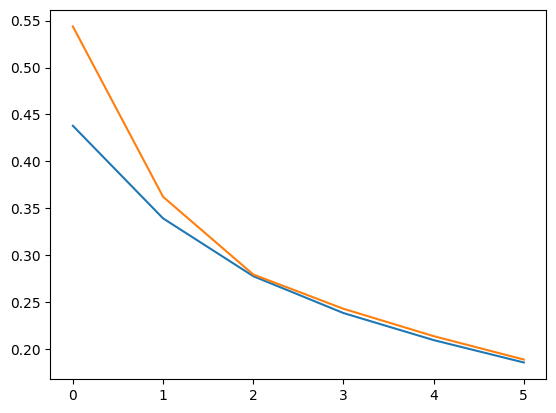

In [1141]:
plt.plot(info1['relError'], label='t_MMGKS1')
plt.plot(info2['relError'], label='t_MMGKS2')

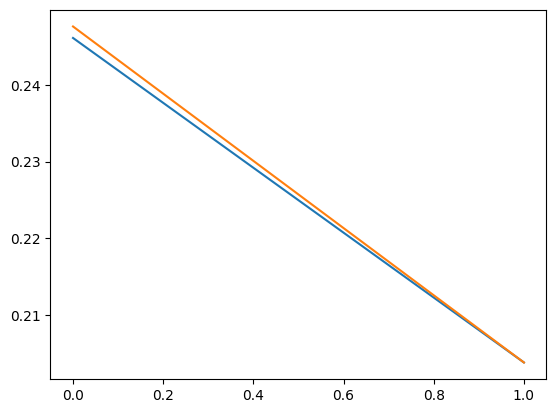

In [1118]:
plt.plot(info1['relError'], label='t_MMGKS1')
plt.plot(info2['relError'], label='t_MMGKS2')

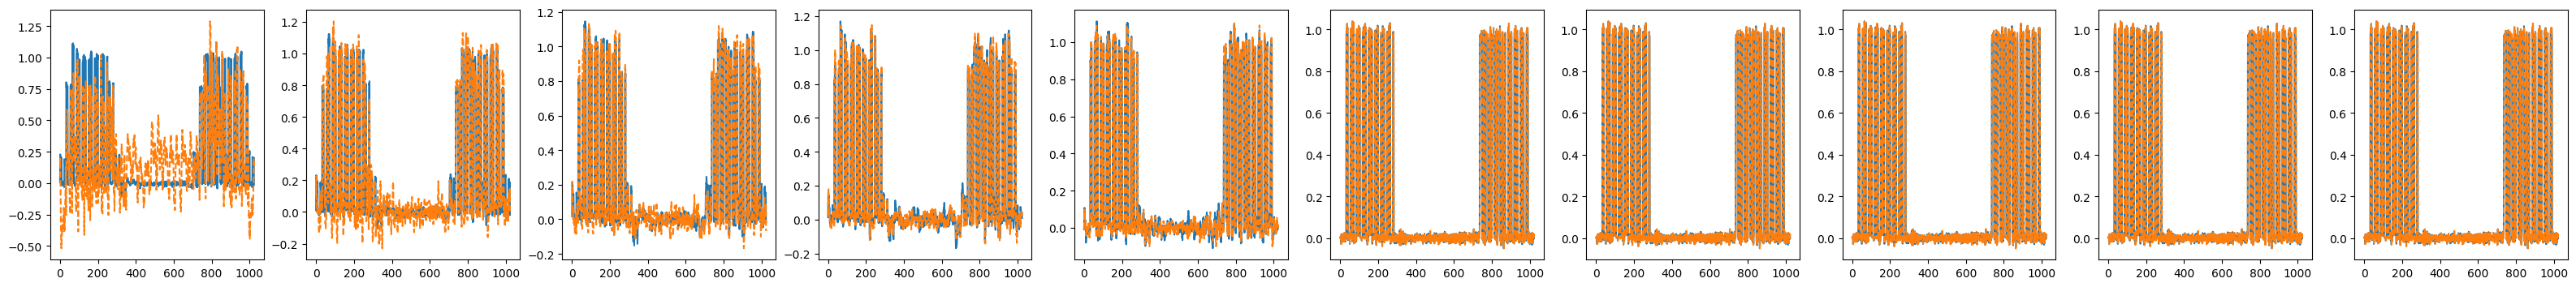

In [981]:
fig,ax = plt.subplots(1,N_ITER, figsize=(4*N_ITER, 4))
for i in range(len(info1['diag'])):
    ax[i].plot(info1['diag'][i]['X'][:,0,:].flatten())
    ax[i].plot(info2['diag'][i]['X'][:,0,:].flatten(),'--')
    

KeyError: 'V'

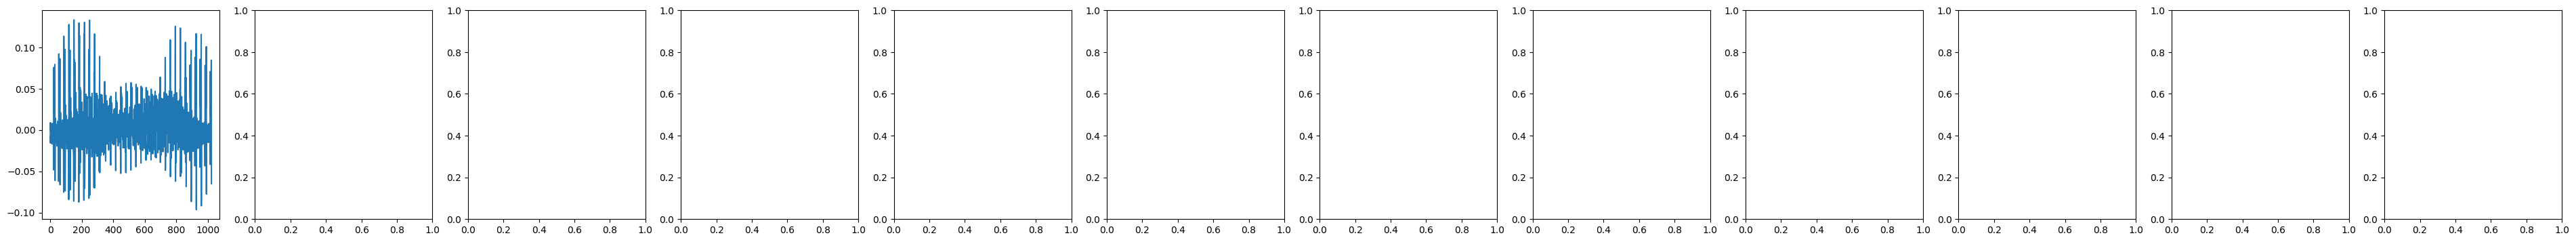

In [944]:
fig,ax = plt.subplots(1,N_ITER, figsize=(4*N_ITER, 4))
for i in range(len(info1['diag'])):
    ax[i].plot(info1['diag'][i]['V'][:,0,:].flatten())
    ax[i].plot(info2['diag'][i]['V'][:,0,:].flatten(),'--')
    

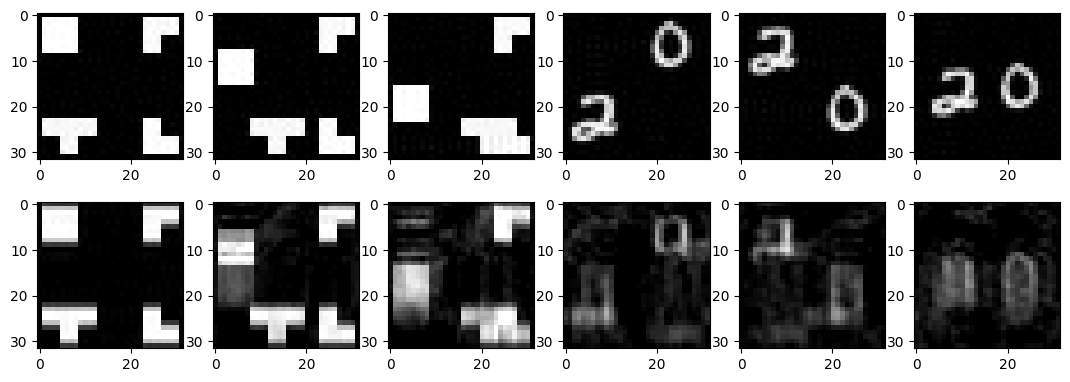

In [982]:
# Show a few frames of true and noisy
n_show = min(N_T, 6)
fig, axs = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.5))

frame_idxs = np.linspace(0, N_T - 1, n_show, dtype=int)
for j, t in enumerate(frame_idxs):
    axs[0,j].imshow(info1['diag'][-1]['X'][:,t,:].reshape(NX,NY), cmap='gray',vmin=0,vmax=1)
    axs[1,j].imshow(info1['diag'][0]['X'][:,t,:].reshape(NX,NY), cmap='gray',vmin=0,vmax=1)
    #ax[i].plot(info2['diag'][i]['X'][:,0,:].flatten())
    

In [950]:
X1.shape, X2.shape

((32, 40, 32), (32, 40, 32))

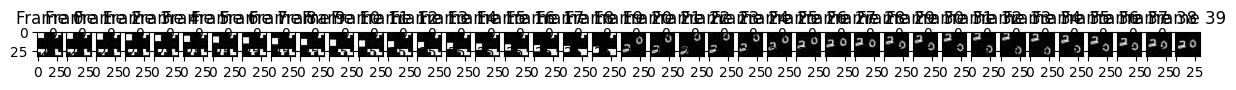

In [951]:
fig, axs = plt.subplots(1, N_T,  figsize=(15, 5))
for j in range(N_T):
    axs[j].imshow(X1[:,j,:].reshape(NX,NY), cmap='gray', vmin=0, vmax=1)
    axs[j].set_title(f"Frame {j}")